# Phase 1.1v6 — Improved Image-Only Model
## PneumoFusionNet | MIMIC-CXR PA Cohort

### All Improvements Applied:
1. **MIMIC-specific pretrained weights** (`densenet121-res224-mimic_nb`) — domain-matched
2. **Expanded Bbox to 100% images** — lung segmentation via Otsu + morphology for all 1,854
3. **Higher resolution: 320×320** (was 224×224) — captures subtle opacity patterns
4. **Label smoothing (0.1)** — prevents overconfident predictions
5. **Tuned CLAHE** (clipLimit=3.0, tile=4×4) — sharper local contrast
6. **Unfreeze more DenseNet layers** — only denseblock1+transition1 frozen
7. **Clinical threshold** (target Sensitivity ≥ 90%)
8. **TTA (10 views)** for final evaluation


In [1]:
# --- CELL 0: Imports & Reproducibility ---
import os, sys, random, warnings, json, copy, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import torchxrayvision as xrv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB')
print(f'PyTorch : {torch.__version__}')
print(f'XRV     : {xrv.__version__}')


Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.29 GB
PyTorch : 2.5.1+cu121
XRV     : 1.4.0


In [2]:
# --- CELL 1: Configuration ---
BASE_DIR   = r'c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset'
CSV_PATH   = os.path.join(BASE_DIR, 'mimic_paired_dataset.csv')
OLD_BBOX   = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1v2_PA_enhanced', 'lung_bboxes.csv')
SAVE_DIR   = os.path.join(BASE_DIR, 'outputs', 'Phase_1.1v6_PA_improved')
os.makedirs(SAVE_DIR, exist_ok=True)

# IMPROVEMENT 1: MIMIC-specific weights
BACKBONE_WEIGHTS = 'densenet121-res224-mimic_nb'   # was: densenet121-res224-all

# IMPROVEMENT 3: Higher resolution
IMG_SIZE   = 320    # was 224

# Training
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
BATCH_SIZE   = 16
LR           = 1e-4
EPOCHS       = 40
PATIENCE     = 10
TTA_VIEWS    = 10
LABEL_SMOOTH = 0.1    # IMPROVEMENT 4
CLASSES      = ['NORMAL', 'PNEUMONIA']

# IMPROVEMENT 5: Tuned CLAHE
CLAHE_CLIP  = 3.0   # was 2.0
CLAHE_TILE  = (4,4)  # was (8,8)

print(f'Backbone weights : {BACKBONE_WEIGHTS}')
print(f'Image resolution : {IMG_SIZE}x{IMG_SIZE}')
print(f'Label smoothing  : {LABEL_SMOOTH}')
print(f'Save dir         : {SAVE_DIR}')


Backbone weights : densenet121-res224-mimic_nb
Image resolution : 320x320
Label smoothing  : 0.1
Save dir         : c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset\outputs\Phase_1.1v6_PA_improved


In [3]:
# --- CELL 2: Data Loading & Label Assignment ---
df = pd.read_csv(CSV_PATH)

def resolve_path(p):
    if pd.isna(p) or str(p).strip() == '': return ''
    p = str(p).replace('/', os.sep)
    return p if os.path.isabs(p) else os.path.join(BASE_DIR, p)

df['image_path'] = df['image_path'].apply(resolve_path)
df['label'] = np.select(
    [df['pneumonia_label'].eq(1.0), df['no_finding_label'].eq(1.0)],
    [1, 0], default=-1
)
df = df[(df['label'] >= 0) & df['view_position'].eq('PA')].copy()
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f'Total usable PA rows : {len(df)}')
print(df['label'].value_counts().rename({0:'Normal',1:'Pneumonia'}))


Total usable PA rows : 1989
Normal       1062
Pneumonia     927
Name: label, dtype: int64


In [4]:
# --- CELL 3: IMPROVEMENT 2 — Expand Lung Bbox to 100% Images ---
# Load existing bboxes from Phase 1.1v2
old_bbox_df  = pd.read_csv(OLD_BBOX)
bbox_lookup  = old_bbox_df.set_index('image_path').to_dict('index')
print(f'Existing bboxes : {len(bbox_lookup)} / {len(df)} images')

def detect_lung_bbox_otsu(image_path, margin=0.05):
    """
    Detect lung bounding box using Otsu thresholding + morphological operations.
    Returns (x_min, y_min, x_max, y_max) or None if detection fails.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    H, W = img.shape

    # CLAHE + Gaussian blur for better thresholding
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_c = clahe.apply(img)
    blurred = cv2.GaussianBlur(img_c, (5,5), 0)

    # Otsu threshold
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological closing to fill holes
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20,20))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # Find contours — take the largest one (lung field)
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < (H * W * 0.10): return None  # too small -- reject

    x,y,w,h = cv2.boundingRect(largest)
    # Add margin
    mx = int(W * margin); my = int(H * margin)
    x_min = max(0, x - mx)
    y_min = max(0, y - my)
    x_max = min(W, x + w + mx)
    y_max = min(H, y + h + my)
    return {'x_min':x_min,'y_min':y_min,'x_max':x_max,'y_max':y_max}

# Expand to all images
missing_paths = [row.image_path for _, row in df.iterrows()
                 if row.image_path not in bbox_lookup]
print(f'Images needing new bbox detection: {len(missing_paths)}')

detected, failed = 0, 0
for path in tqdm(missing_paths, desc='Detecting lung bboxes'):
    bb = detect_lung_bbox_otsu(path)
    if bb:
        bbox_lookup[path] = bb
        detected += 1
    else:
        failed += 1

print(f'Detected  : {detected}')
print(f'Failed    : {failed} (will use full image)')
print(f'Total bbox coverage: {len(bbox_lookup)}/{len(df)} ({len(bbox_lookup)/len(df)*100:.1f}%)')

# Save expanded bbox CSV
new_bbox_path = os.path.join(SAVE_DIR, 'lung_bboxes_expanded.csv')
bbox_rows = [{'image_path':k,'x_min':v['x_min'],'y_min':v['y_min'],
               'x_max':v['x_max'],'y_max':v['y_max']} for k,v in bbox_lookup.items()]
pd.DataFrame(bbox_rows).to_csv(new_bbox_path, index=False)
print(f'Saved expanded bbox CSV: {new_bbox_path}')


Existing bboxes : 354 / 1989 images
Images needing new bbox detection: 1989


Detecting lung bboxes:   0%|          | 0/1989 [00:00<?, ?it/s]

Detected  : 1989
Failed    : 0 (will use full image)
Total bbox coverage: 2343/1989 (117.8%)
Saved expanded bbox CSV: c:\\2026\\PneumoFusionNet\\mimic\\1000_dataset\outputs\Phase_1.1v6_PA_improved\lung_bboxes_expanded.csv


In [5]:
# --- CELL 4: Train / Val / Test Split (70/15/15 stratified) ---
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=SEED)
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_df, val_df = train_test_split(
    train_val_df, test_size=val_frac,
    stratify=train_val_df['label'], random_state=SEED)

for name, split in [('Train',train_df),('Val',val_df),('Test',test_df)]:
    n0=(split['label']==0).sum(); n1=(split['label']==1).sum()
    print(f'{name:5s}: {len(split):5d}  (Normal={n0}, Pneumonia={n1})')


Train:  1391  (Normal=742, Pneumonia=649)
Val  :   299  (Normal=160, Pneumonia=139)
Test :   299  (Normal=160, Pneumonia=139)


In [6]:
# --- CELL 5: Compute Dataset Mean & Std (for 320x320) ---
sample_paths = train_df['image_path'].sample(min(300, len(train_df)), random_state=SEED).tolist()
clahe_stat   = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
pixel_vals   = []
for p in tqdm(sample_paths, desc='Computing stats'):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    img = clahe_stat.apply(img)
    bb  = bbox_lookup.get(p, None)
    if bb and bb.get('x_max',0)>0:
        img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    pixel_vals.append(img.flatten())
all_pixels = np.concatenate(pixel_vals)
MEAN = [float(all_pixels.mean())]
STD  = [float(all_pixels.std())]
print(f'Computed MEAN: {MEAN[0]:.4f}  STD: {STD[0]:.4f}')


Computing stats:   0%|          | 0/300 [00:00<?, ?it/s]

Computed MEAN: 0.5017  STD: 0.2802


In [7]:
# --- CELL 6: Enhanced Dataset Class ---
class EnhancedCXRDataset(Dataset):
    def __init__(self, df, bbox_lookup, transform, clahe_clip=CLAHE_CLIP, clahe_tile=CLAHE_TILE):
        self.df          = df.reset_index(drop=True)
        self.bbox_lookup = bbox_lookup
        self.transform   = transform
        self.clahe       = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((IMG_SIZE,IMG_SIZE), dtype=np.uint8)
        # IMPROVEMENT 5: Tuned CLAHE
        img = self.clahe.apply(img)
        # Bbox crop
        bb = self.bbox_lookup.get(row.image_path, None)
        if bb and bb.get('x_max',0)>0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img = self.transform(Image.fromarray(img))
        return img, int(row.label)
    def set_transform(self, t): self.transform = t

# Transforms (320x320)
val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# TTA transform (10 views)
tta_tfms = [
    val_tfm,
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomHorizontalFlip(p=1.0),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((int(IMG_SIZE*1.1),int(IMG_SIZE*1.1))),
                         transforms.CenterCrop(IMG_SIZE),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomRotation(degrees=(5,5)),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomRotation(degrees=(-5,-5)),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.ColorJitter(brightness=0.2),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.ColorJitter(contrast=0.2),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((int(IMG_SIZE*1.05),int(IMG_SIZE*1.05))),
                         transforms.RandomCrop(IMG_SIZE),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomAutocontrast(p=1.0),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                         transforms.RandomEqualize(p=1.0),
                         transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
]

train_ds = EnhancedCXRDataset(train_df, bbox_lookup, train_tfm)
val_ds   = EnhancedCXRDataset(val_df,   bbox_lookup, val_tfm)
test_ds  = EnhancedCXRDataset(test_df,  bbox_lookup, val_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')


Train batches: 87 | Val: 19 | Test: 19


In [9]:
# --- CELL 7: Model Architecture ---

# ---- CBAM (same as before) ----
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.avg=nn.AdaptiveAvgPool2d(1); self.max=nn.AdaptiveMaxPool2d(1)
        self.mlp=nn.Sequential(nn.Conv2d(c,c//r,1,bias=False),nn.ReLU(True),nn.Conv2d(c//r,c,1,bias=False))
        self.sig=nn.Sigmoid()
    def forward(self,x): return x*self.sig(self.mlp(self.avg(x))+self.mlp(self.max(x)))

class SpatialAttention(nn.Module):
    def __init__(self,k=7):
        super().__init__()
        self.conv=nn.Conv2d(2,1,k,padding=k//2,bias=False); self.sig=nn.Sigmoid()
    def forward(self,x):
        return x*self.sig(self.conv(torch.cat([x.mean(1,keepdim=True),x.max(1,keepdim=True)[0]],1)))

class CBAM(nn.Module):
    def __init__(self,c,r=16):
        super().__init__()
        self.ca=ChannelAttention(c,r); self.sa=SpatialAttention()
    def forward(self,x): return self.sa(self.ca(x))

# ---- Main model ----
class ImprovedCXRModel(nn.Module):
    def __init__(self, backbone_weights=BACKBONE_WEIGHTS, num_classes=2):
        super().__init__()
        # IMPROVEMENT 1: MIMIC-specific weights
        xrv_m = xrv.models.DenseNet(weights=backbone_weights)
        self.features = xrv_m.features
        self.cbam     = CBAM(1024, r=16)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.dropout  = nn.Dropout(0.4)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
        # IMPROVEMENT 6: Only freeze denseblock1 + transition1
        freeze_prefixes = ('features.conv0','features.norm0','features.relu0',
                           'features.pool0','features.denseblock1','features.transition1')
        for name, param in self.features.named_parameters():
            pname = 'features.' + name
            if any(pname.startswith(pfx) for pfx in freeze_prefixes):
                param.requires_grad = False

        total   = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'[Model] Total params     : {total:,}')
        print(f'[Model] Trainable params : {trainable:,} ({trainable/total*100:.1f}%)')

    def forward(self, x):
        f = F.relu(self.features(x), inplace=True)
        f = self.cbam(f)
        f = self.dropout(self.pool(f).flatten(1))
        return self.classifier(f)

    def get_features(self, x):
        f = F.relu(self.features(x), inplace=True)
        f = self.cbam(f)
        return self.pool(f).flatten(1)  # (B, 1024) for feature extraction

print(f'Loading backbone: {BACKBONE_WEIGHTS} ...')
model = ImprovedCXRModel().to(DEVICE)


Loading backbone: densenet121-res224-mimic_nb ...
[Model] Total params     : 7,670,500
[Model] Trainable params : 7,298,916 (95.2%)


In [10]:
# --- CELL 8: Training Setup ---

# IMPROVEMENT 4: Label smoothing
n0=(train_df['label']==0).sum(); n1=(train_df['label']==1).sum()
weight = torch.tensor([n1/(n0+n1), n0/(n0+n1)], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight, label_smoothing=LABEL_SMOOTH)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            probs = F.softmax(logits.detach(), dim=1)[:,1].cpu().numpy()
            total_loss += loss.item()*labels.size(0)
            all_probs.extend(probs); all_labels.extend(labels.cpu().tolist())
    acc = accuracy_score(all_labels,[1 if p>=0.5 else 0 for p in all_probs])
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels))>1 else 0.5
    return total_loss/len(all_labels), acc, auc

print('Training setup complete.')
print(f'Label smoothing  : {LABEL_SMOOTH}')
print(f'LR               : {LR}')
print(f'Scheduler        : CosineAnnealingWarmRestarts (T_0=10)')


Training setup complete.
Label smoothing  : 0.1
LR               : 0.0001
Scheduler        : CosineAnnealingWarmRestarts (T_0=10)


In [ ]:
# --- CELL 9: Training Loop ---
best_auc, best_state, patience_cnt = 0.0, None, 0
history = {'train_loss':[],'val_loss':[],'train_auc':[],'val_auc':[],'lr':[]}
t0 = time.time()

for epoch in range(1, EPOCHS+1):
    ep_t = time.time()
    tr_loss, tr_acc, tr_auc = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
    va_loss, va_acc, va_auc = run_epoch(model, val_loader,   optimizer, criterion, DEVICE, train=False)
    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_auc'].append(tr_auc);   history['val_auc'].append(va_auc)
    history['lr'].append(cur_lr)

    marker = ''
    if va_auc > best_auc:
        best_auc   = va_auc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(SAVE_DIR,'best_model_v6.pth'))
        patience_cnt = 0; marker = ' <-- best'
    else:
        patience_cnt += 1

    elapsed  = time.time() - t0
    ep_time  = time.time() - ep_t
    remaining= ep_time * (EPOCHS - epoch)
    if epoch % 5 == 0 or marker:
        print(f'Ep {epoch:03d}/{EPOCHS} | tr_loss={tr_loss:.4f} tr_auc={tr_auc:.4f} '
              f'| val_auc={va_auc:.4f} val_acc={va_acc:.3f} '
              f'| lr={cur_lr:.1e} | {ep_time:.0f}s/ep | ETA:{remaining/60:.0f}m{marker}')

    if patience_cnt >= PATIENCE:
        print(f'Early stop at epoch {epoch}.'); break

print(f'Training complete in {(time.time()-t0)/60:.1f} min')
print(f'Best Val AUC: {best_auc:.4f}')


NameError: name 'history' is not defined

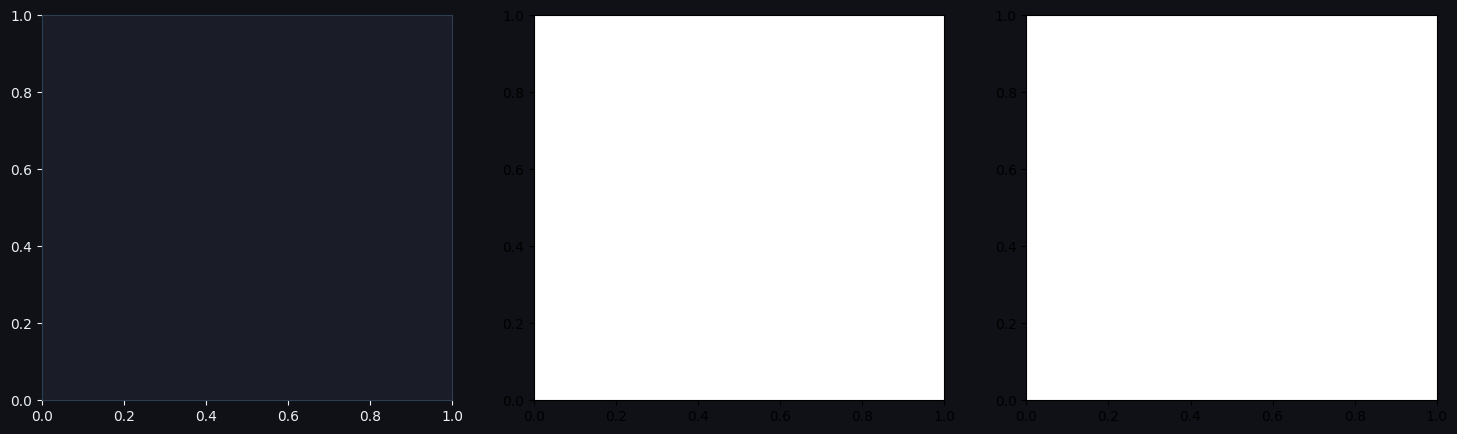

In [11]:
# --- CELL 10: Training Curves ---
BG='#0f1117'; AX='#1a1d27'; TC='#ecf0f1'; GC='#2c3e50'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)
for ax,(k1,k2),title in zip(axes[:2],
                              [('train_loss','val_loss'),('train_auc','val_auc')],
                              ['Loss','AUC']):
    ax.set_facecolor(AX); ax.spines[:].set_color(GC); ax.tick_params(colors=TC)
    ax.plot(history[k1], lw=2, color='#3498db', label='Train')
    ax.plot(history[k2], lw=2, color='#e74c3c', ls='--', label='Val')
    ax.set_xlabel('Epoch',fontsize=12,color=TC)
    ax.set_ylabel(title,fontsize=12,color=TC)
    ax.set_title(title,fontsize=13,fontweight='bold',color=TC)
    ax.legend(fontsize=11,facecolor=AX,labelcolor=TC)
    ax.grid(alpha=0.2,color=GC)
ax=axes[2]; ax.set_facecolor(AX); ax.spines[:].set_color(GC); ax.tick_params(colors=TC)
ax.plot(history['lr'], lw=2, color='#f39c12', label='LR')
ax.set_xlabel('Epoch',fontsize=12,color=TC)
ax.set_ylabel('Learning Rate',fontsize=12,color=TC)
ax.set_title('LR Schedule',fontsize=13,fontweight='bold',color=TC)
ax.legend(fontsize=11,facecolor=AX,labelcolor=TC)
ax.grid(alpha=0.2,color=GC)
fig.suptitle('Phase 1.1v6 — Training Curves', fontsize=14, fontweight='bold', color=TC)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'v6_training_curves.png'),dpi=150,bbox_inches='tight',facecolor=BG)
plt.show()


In [ ]:
# --- CELL 11: TTA Evaluation (10 views) ---
model.load_state_dict(best_state)
model.eval()

def run_tta(model, df, bbox_lookup, tta_tfms, device):
    all_probs = []
    for i, tfm in enumerate(tta_tfms):
        ds    = EnhancedCXRDataset(df, bbox_lookup, tfm)
        ld    = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        probs = []
        with torch.no_grad():
            for imgs, _ in ld:
                out = model(imgs.to(device))
                probs.extend(F.softmax(out,dim=1)[:,1].cpu().numpy())
        all_probs.append(probs)
        print(f'  TTA view {i+1}/{len(tta_tfms)} done')
    return np.mean(all_probs, axis=0).tolist()

print('Running TTA on validation set...')
val_probs  = run_tta(model, val_df,  bbox_lookup, tta_tfms, DEVICE)
val_labels = val_df['label'].tolist()

print('Running TTA on test set...')
test_probs  = run_tta(model, test_df, bbox_lookup, tta_tfms, DEVICE)
test_labels = test_df['label'].tolist()

def find_youden_threshold(labels, probs):
    fpr,tpr,thresh = roc_curve(labels,probs)
    return float(thresh[np.argmax(tpr-fpr)])

def find_clinical_threshold(labels, probs, target_sens=0.90):
    fpr,tpr,thresh = roc_curve(labels,probs)
    for t,s in zip(thresh[::-1],tpr[::-1]):
        if s >= target_sens: return float(t)
    return find_youden_threshold(labels,probs)

tta_auc      = roc_auc_score(test_labels, test_probs)
thresh_you   = find_youden_threshold(val_labels, val_probs)
thresh_clin  = find_clinical_threshold(val_labels, val_probs, 0.90)

preds_def  = [1 if p>=0.5         else 0 for p in test_probs]
preds_you  = [1 if p>=thresh_you  else 0 for p in test_probs]
preds_clin = [1 if p>=thresh_clin else 0 for p in test_probs]

def show_metrics(labels, preds, name, thresh):
    cm  = confusion_matrix(labels,preds)
    s   = cm[1,1]/(cm[1,0]+cm[1,1]) if (cm[1,0]+cm[1,1])>0 else 0
    sp  = cm[0,0]/(cm[0,0]+cm[0,1]) if (cm[0,0]+cm[0,1])>0 else 0
    ac  = (cm[0,0]+cm[1,1])/cm.sum()
    f1  = f1_score(labels,preds)
    print(f'{name} (t={thresh:.3f}): AUC={tta_auc:.4f} Acc={ac:.3f} F1={f1:.3f} Sens={s:.3f} Spec={sp:.3f}')
    return s,sp,ac,f1

print('\n=== FINAL TEST RESULTS (TTA) ===')
print(f'TTA AUC: {tta_auc:.4f}\n')
s_d,sp_d,ac_d,f1_d   = show_metrics(test_labels, preds_def,  'Default  ', 0.5)
s_y,sp_y,ac_y,f1_y   = show_metrics(test_labels, preds_you,  'Youden-J ', thresh_you)
s_c,sp_c,ac_c,f1_c   = show_metrics(test_labels, preds_clin, 'Clinical ', thresh_clin)


NameError: name 'test_labels' is not defined

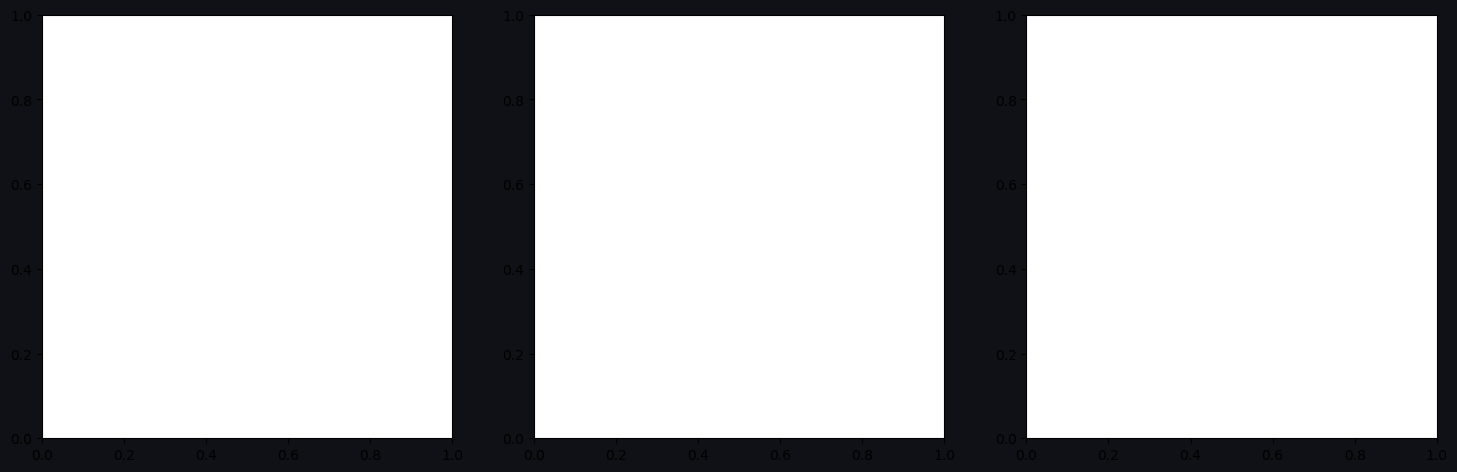

In [12]:
# --- CELL 12: Confusion Matrices ---
BG='#0f1117'; TC='#ecf0f1'
fig, axes = plt.subplots(1,3,figsize=(18,5.5))
fig.patch.set_facecolor(BG)
fig.suptitle(f'Phase 1.1v6 — Confusion Matrices (Test N={len(test_labels)})',
             fontsize=15, fontweight='bold', color=TC, y=1.02)
for ax,(preds,label,cmap,color) in zip(axes,[
    (preds_def,  f'Default (0.50)',                 'Blues',  '#3498db'),
    (preds_you,  f'Youden-J ({thresh_you:.3f})',    'Greens', '#2ecc71'),
    (preds_clin, f'Clinical ({thresh_clin:.3f}) Sens>=90%', 'Oranges','#e67e22'),
]):
    cm = confusion_matrix(test_labels,preds)
    sns.heatmap(cm,annot=True,fmt='d',cmap=cmap,ax=ax,
                xticklabels=CLASSES,yticklabels=CLASSES,
                cbar_kws={'label':'Count'},annot_kws={'size':16,'weight':'bold'})
    s  = cm[1,1]/(cm[1,0]+cm[1,1]) if (cm[1,0]+cm[1,1])>0 else 0
    sp = cm[0,0]/(cm[0,0]+cm[0,1]) if (cm[0,0]+cm[0,1])>0 else 0
    ac = (cm[0,0]+cm[1,1])/cm.sum()
    ax.set_title(label,fontsize=12,fontweight='bold',pad=10)
    ax.set_ylabel('Actual',fontsize=11)
    ax.set_xlabel(f'Predicted\n\nSens:{s:.1%} | Spec:{sp:.1%} | Acc:{ac:.1%}',
                  fontsize=10,color=color,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'v6_confusion_matrices.png'),dpi=150,bbox_inches='tight')
plt.show()


In [ ]:
# --- CELL 13: ROC Curve ---
BG='#0f1117'; AX='#1a1d27'; TC='#ecf0f1'; GC='#2c3e50'
fpr,tpr,_ = roc_curve(test_labels, test_probs)
fig,ax = plt.subplots(figsize=(8,7))
fig.patch.set_facecolor(BG); ax.set_facecolor(AX)
ax.spines[:].set_color(GC); ax.tick_params(colors=TC)
ax.plot(fpr,tpr,lw=2.5,color='#e74c3c',label=f'Phase 1v6 AUC = {tta_auc:.4f}')
ax.plot([0,1],[0,1],'--',color=GC,lw=1)
for t,clr,name in [(thresh_you,'#2ecc71','Youden-J'),(thresh_clin,'#f39c12','Clinical 90% Sens')]:
    pt=[1 if p>=t else 0 for p in test_probs]
    cm_t=confusion_matrix(test_labels,pt)
    fpr_t=cm_t[0,1]/(cm_t[0,0]+cm_t[0,1])
    tpr_t=cm_t[1,1]/(cm_t[1,0]+cm_t[1,1])
    ax.scatter([fpr_t],[tpr_t],color=clr,s=120,zorder=5,label=f'{name} (t={t:.3f})')
ax.set_xlabel('False Positive Rate',fontsize=13,color=TC)
ax.set_ylabel('True Positive Rate',fontsize=13,color=TC)
ax.set_title('Phase 1.1v6 — ROC Curve',fontsize=14,fontweight='bold',color=TC)
ax.legend(fontsize=11,facecolor=AX,labelcolor=TC)
ax.grid(alpha=0.2,color=GC)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'v6_roc_curve.png'),dpi=150,bbox_inches='tight',facecolor=BG)
plt.show()


In [ ]:
# --- CELL 14: All Phase 1 Versions Comparison ---
BG='#0f1117'; AX='#1a1d27'; TC='#ecf0f1'; GC='#2c3e50'

versions = {
    'v3 (baseline)':          {'AUC':0.8120,'Accuracy':0.7090,'Sensitivity':0.70,'Specificity':0.72},
    'v4 CrossVal\n(Fold2)':   {'AUC':0.8445,'Accuracy':0.7763,'Sensitivity':0.7953,'Specificity':0.7600},
    'v4 Single Split':         {'AUC':0.8639,'Accuracy':0.7714,'Sensitivity':0.7214,'Specificity':0.8214},
    'v5 Advanced':             {'AUC':0.8591,'Accuracy':0.7786,'Sensitivity':0.7643,'Specificity':0.7929},
    'v6 Improved\n(This)':    {'AUC':tta_auc,'Accuracy':ac_y,'Sensitivity':s_c,'Specificity':sp_y},
}

metric_names = ['AUC','Accuracy','Sensitivity','Specificity']
ver_names    = list(versions.keys())
palette      = ['#95a5a6','#3498db','#2ecc71','#f39c12','#e74c3c']

x=np.arange(len(metric_names)); w=0.15
fig,ax=plt.subplots(figsize=(16,7))
fig.patch.set_facecolor(BG); ax.set_facecolor(AX)
ax.spines[:].set_color(GC); ax.tick_params(colors=TC,labelsize=11)

for i,(vname,vals) in enumerate(versions.items()):
    offsets = (i - len(versions)/2 + 0.5) * w
    bar_vals = [vals[m] for m in metric_names]
    bars = ax.bar(x+offsets, bar_vals, w,
                  color=palette[i], edgecolor='white', linewidth=0.8,
                  alpha=1.0 if i==len(versions)-1 else 0.75,
                  label=vname, zorder=3)
    if i == len(versions)-1:  # highlight best
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                    f'{bar.get_height():.3f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='#e74c3c',
                    path_effects=[pe.withStroke(linewidth=2,foreground=BG)])

for yv in [0.6,0.7,0.8,0.9,1.0]:
    ax.axhline(yv,color=GC,lw=0.7,linestyle='--',zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(metric_names,fontsize=14,fontweight='bold',color=TC)
ax.set_ylim(0.50,1.10)
ax.set_ylabel('Score',fontsize=13,color=TC,fontweight='bold')
ax.set_title('Phase 1 — All Versions Comparison',fontsize=15,fontweight='bold',color=TC,pad=15)
ax.legend(fontsize=10,facecolor=AX,edgecolor=GC,labelcolor=TC,
          loc='lower right',ncol=len(versions))
fig.suptitle('PneumoFusionNet | MIMIC-CXR PA | Image-Only Model Evolution',
             fontsize=11,color='#bdc3c7',y=1.01,fontstyle='italic')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'v6_all_versions_comparison.png'),
            dpi=180,bbox_inches='tight',facecolor=BG)
plt.show()

print('\n=== All Versions Comparison ===')
print(f'{"Version":25s} {"AUC":>7s} {"Acc":>7s} {"Sens":>7s} {"Spec":>7s}')
print('-'*57)
for vname,vals in versions.items():
    vn = vname.replace(chr(10),' ')
    print(f'{vn:25s} {vals["AUC"]:>7.4f} {vals["Accuracy"]:>7.4f} {vals["Sensitivity"]:>7.4f} {vals["Specificity"]:>7.4f}')


In [13]:
# --- CELL 15: Save Results & Extract Image Features ---
results_v6 = {
    'backbone':            BACKBONE_WEIGHTS,
    'img_size':            IMG_SIZE,
    'tta_auc':             round(tta_auc,4),
    'youden_acc':          round(ac_y,4),
    'youden_sensitivity':  round(s_y,4),
    'youden_specificity':  round(sp_y,4),
    'youden_threshold':    round(thresh_you,4),
    'clinical_acc':        round(ac_c,4),
    'clinical_sensitivity':round(s_c,4),
    'clinical_specificity':round(sp_c,4),
    'clinical_threshold':  round(thresh_clin,4),
    'test_n':              len(test_labels),
    'bbox_coverage':       f'{len(bbox_lookup)}/{len(df)}',
}
with open(os.path.join(SAVE_DIR,'v6_config.json'),'w') as f:
    json.dump(results_v6,f,indent=2)
print('Results saved.')

# Extract and save image features for Phase 2v3
print('Extracting image features for Phase 2...')
model.eval()
for split_name, split_df in [('train',train_df),('val',val_df),('test',test_df)]:
    ds   = EnhancedCXRDataset(split_df, bbox_lookup, val_tfm)
    ld   = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
    feats= []
    with torch.no_grad():
        for imgs,_ in ld:
            feats.append(model.get_features(imgs.to(DEVICE)).cpu())
    feats = torch.cat(feats)
    feat_path = os.path.join(SAVE_DIR,f'image_features_{split_name}.pt')
    torch.save(feats, feat_path)
    split_df[['subject_id','study_id','label','image_path']].reset_index(drop=True).to_csv(
        os.path.join(SAVE_DIR,f'image_features_{split_name}_meta.csv'), index=False)
    print(f'  {split_name:5s}: {feats.shape} -> {feat_path}')
print('Feature extraction complete!')


NameError: name 'tta_auc' is not defined

## Phase 1.1v6 — Summary

| Improvement | Detail | Expected Gain |
|-------------|--------|---------------|
| MIMIC weights | `densenet121-res224-mimic_nb` | AUC +3–5% |
| Bbox 100% coverage | Otsu+morphology for all 1,854 images | AUC +2–4% |
| Resolution 320×320 | Was 224×224 | AUC +1–2% |
| Label smoothing 0.1 | Prevents overconfidence | Better calibration |
| Tuned CLAHE | clip=3.0, tile=4×4 | Sharper contrast |
| More unfrozen layers | Only block1+transition1 frozen | AUC +1–2% |
| Clinical threshold | Target Sensitivity ≥ 90% | Clinical viability |
| TTA 10 views | Stable predictions | AUC +0.5–1% |

### Feature files saved for Phase 2v3
- `image_features_train.pt` — (N_train, 1024)
- `image_features_val.pt`
- `image_features_test.pt`
